In [17]:
from lgdo.lh5 import read, read_as, ls, show
from dspeed.vis import WaveformBrowser
from dspeed import units
from dspeed import build_dsp

import matplotlib.pyplot as plt
import os
from legendtestdata import LegendTestData

ldata = LegendTestData()
data_file = ldata.get_path("lh5/LDQTA_r117_20200110T105115Z_cal_geds_raw.lh5")
entry_no = 2  # which waveform in our example data_file to use for plotting

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["font.size"] = 12

In [18]:
dsp_config = {
    "outputs": [
        "timestamp",
        "channel",
        "trapEmax",
        "trapTmax",
        "tp_0",
        "ftp",
        "trapEftp",
        "bl",
        "bl_sig",
        "A_gaus",
    ],
    "processors": {
        "max_index": {
            "function": "argmax",
            "module": "numpy",
            "args": ["waveform", 1, "max_index"],
            "kwargs": {"signature": "(n),()->()", "types": ["fi->i"]},
            "unit": "ADC",
        },
        "bl, bl_sig, slope, intercept": {
            "function": "linear_slope_fit",
            "module": "dspeed.processors",
            "args": ["waveform[:1650]", "bl", "bl_sig", "slope", "intercept"],
            "unit": ["ADC", "ADC", "ADC", "ADC"],
        },
        "wf_blsub": {
            "function": "subtract",
            "module": "numpy",
            "args": ["waveform", "bl", "wf_blsub"],
            "unit": "ADC",
        },
        "wf_pz": {
            "function": "pole_zero",
            "module": "dspeed.processors",
            "args": ["wf_blsub", "180*us", "wf_pz"],
            "unit": "ADC",
        },
        "wf_trap": {
            "function": "trap_norm",
            "module": "dspeed.processors",
            "args": ["wf_pz", "8*us", "2*us", "wf_trap"],
            "unit": "ADC",
        },
        "trapEmax": {
            "function": "amax",
            "module": "numpy",
            "args": ["wf_trap", 1, "trapEmax"],
            "kwargs": {"signature": "(n),()->()", "types": ["fi->f"]},
            "unit": "ADC",
        },
        "trapTmax": {
            "function": "argmax",
            "module": "numpy",
            "args": ["wf_trap", 1, "trapTmax"],
            "kwargs": {"signature": "(n),()->()", "types": ["fi->i"]},
            "unit": "ns",
        },
        "wf_atrap": {
            "function": "asym_trap_filter",
            "module": "dspeed.processors",
            "args": [
                "wf_pz",
                "0.1*us",
                "1*us",
                "3*us",
                "wf_atrap",
            ],  # rising edge, flat section, falling edge
            "unit": "ADC",
        },
        "tmax": {
            "function": "argmax",
            "module": "numpy",
            "args": ["wf_atrap", 1, "tmax"],
            "kwargs": {"signature": "(n),()->()", "types": ["fi->i"]},
            "unit": "ns",
        },
        "tp_0": {
            "function": "time_point_thresh",
            "module": "dspeed.processors",
            "args": ["wf_atrap", 0, "tmax", 0, "tp_0"],
            "unit": "ns",
        },
        "ftp": {
            "function": "add",
            "module": "numpy",
            "args": ["tp_0", "2*us+8*us-256*ns", "ftp"],
            "unit": "ns",
        },
        "trapEftp": {
            "function": "fixed_time_pickoff",
            "module": "dspeed.processors",
            "args": ["wf_trap", "ftp", "105", "trapEftp"],  # ord('i') == 105
            "unit": "ADC",
        },
        "curr": {
            "function": "avg_current",
            "module": "dspeed.processors",
            "args": ["wf_pz", 1, "curr(len(wf_pz)-1, 'f', period=waveform.period)"],
            "unit": "ADC/sample",
        },
        "gaus_kernel": {
            "function": "gaussian_filter1d",
            "module": "dspeed.processors",
            "args": ["50", "4", "gaus_kernel(shape=401, dtype='d')"],
        },
        "curr_gaus": {
            "function": "reflected_convolve_wf",
            "module": "dspeed.processors",
            "args": [
                "curr",
                "gaus_kernel",
                "curr_gaus(len(curr), 'f', period=waveform.period)",
            ],
            "unit": "ADC/sample",
        },
        "A_gaus": {
            "function": "amax",
            "module": "numpy",
            "args": ["curr_gaus", 1, "A_gaus"],
            "kwargs": {"signature": "(n),()->()", "types": ["fi->f"]},
            "unit": "ADC/sample",
        },
    },
}

Found waveforms dict_keys(['waveform']). Use the lines argument to select one or more.


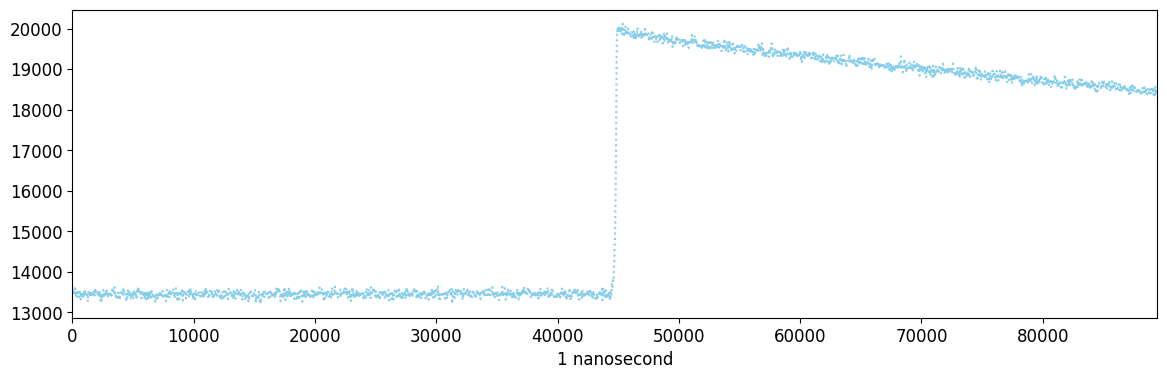

In [19]:
browser = WaveformBrowser(
    data_file,
    "geds/raw",
    styles=[
        {"color": ["skyblue"], "ls": ["dotted"]},
    ],
)
browser.draw_entry(entry_no)

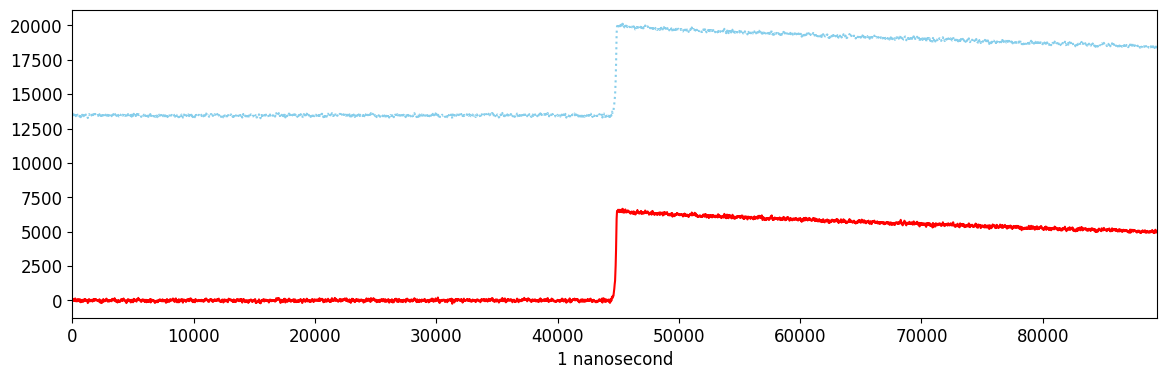

In [20]:
browser = WaveformBrowser(
    data_file,
    "geds/raw",
    dsp_config=dsp_config,
    lines=["waveform", "wf_blsub"],
    styles=[
        {"color": ["skyblue"], "ls": ["dotted"]},
        {"color": ["r"]},
    ],
)
browser.draw_entry(entry_no)

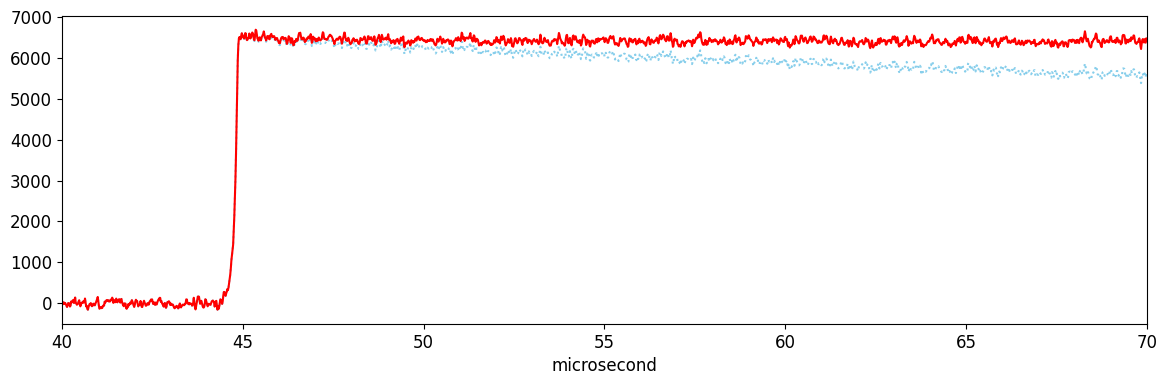

In [21]:
browser = WaveformBrowser(
    data_file,
    "geds/raw",
    dsp_config=dsp_config,
    lines=["wf_blsub", "wf_pz"],
    styles=[
        {"color": ["skyblue"], "ls": [":"]},
        {"color": ["r"]},
    ],
    x_lim=("40*us", "70*us"),
)
browser.draw_entry(entry_no)

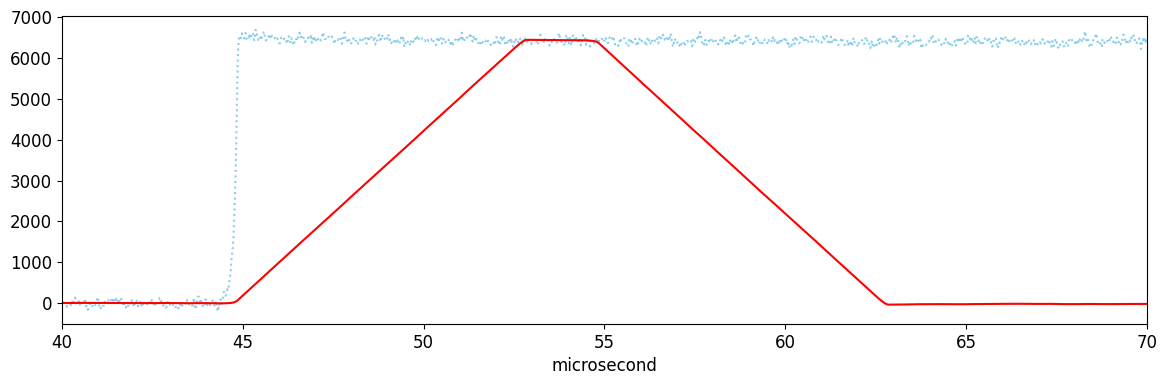

In [22]:
browser = WaveformBrowser(
    data_file,
    "geds/raw",
    dsp_config=dsp_config,
    lines=["wf_pz", "wf_trap"],
    styles=[
        {"color": ["skyblue"], "ls": [":"]},
        {"color": ["r"]},
    ],
    x_lim=("40*us", "70*us"),
)
browser.draw_entry(entry_no)

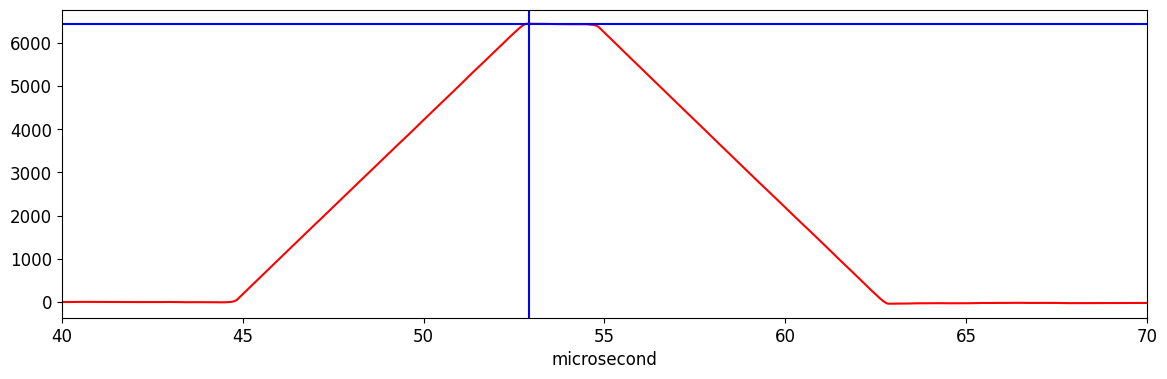

In [23]:
browser = WaveformBrowser(
    data_file,
    "geds/raw",
    dsp_config=dsp_config,
    lines=["wf_trap", "trapEmax", "trapTmax"],
    styles=[
        {"color": ["r"]},
        {"color": ["b"]},
        {"color": ["b"]},
    ],
    x_lim=("40*us", "70*us"),
)
browser.draw_entry(entry_no)

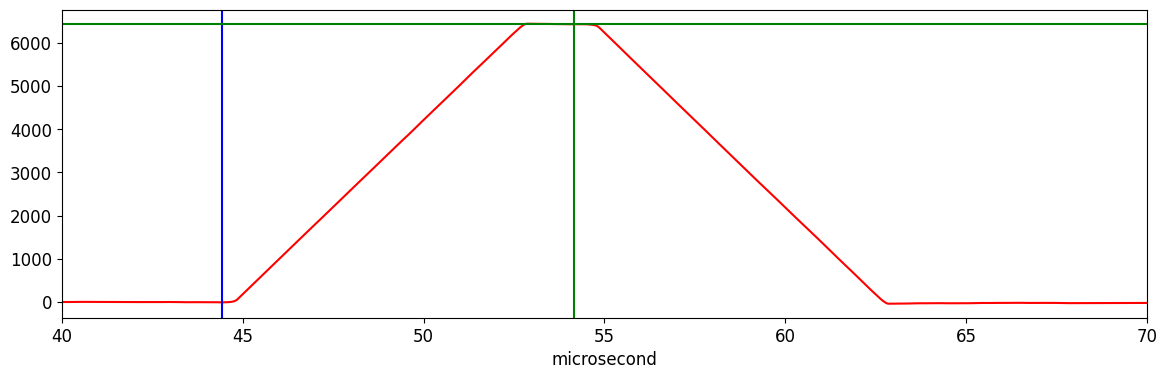

In [24]:
browser = WaveformBrowser(
    data_file,
    "geds/raw",
    dsp_config=dsp_config,
    lines=["wf_trap", "tp_0", "ftp", "trapEftp"],
    styles=[
        {"color": ["r"]},
        {"color": ["b"]},
        {"color": ["g"]},
        {"color": ["g"]},
    ],
    x_lim=("40*us", "70*us"),
)
browser.draw_entry(entry_no)

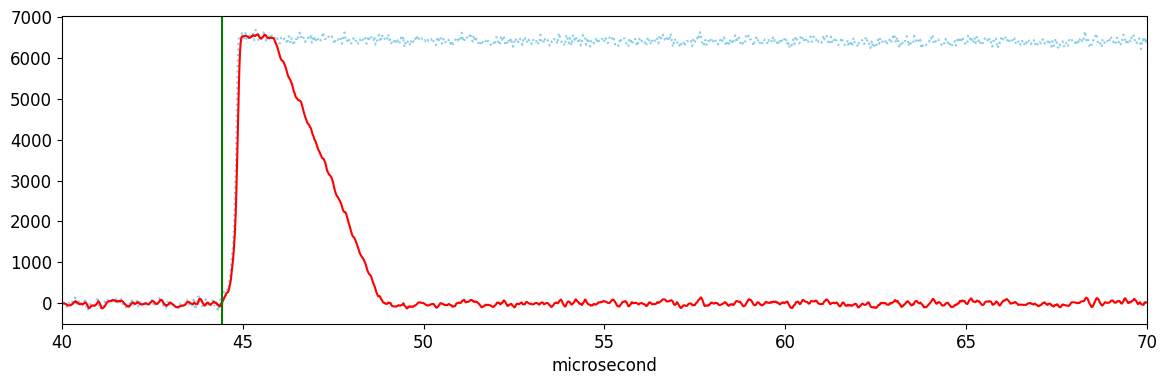

In [25]:
browser = WaveformBrowser(
    data_file,
    "geds/raw",
    dsp_config=dsp_config,
    lines=["wf_pz", "wf_atrap", "tp_0"],
    styles=[
        {"color": ["skyblue"], "ls": [":"]},
        {"color": ["r"]},
        {"color": ["g"]},
    ],
    x_lim=("40*us", "70*us"),
)
browser.draw_entry(entry_no)

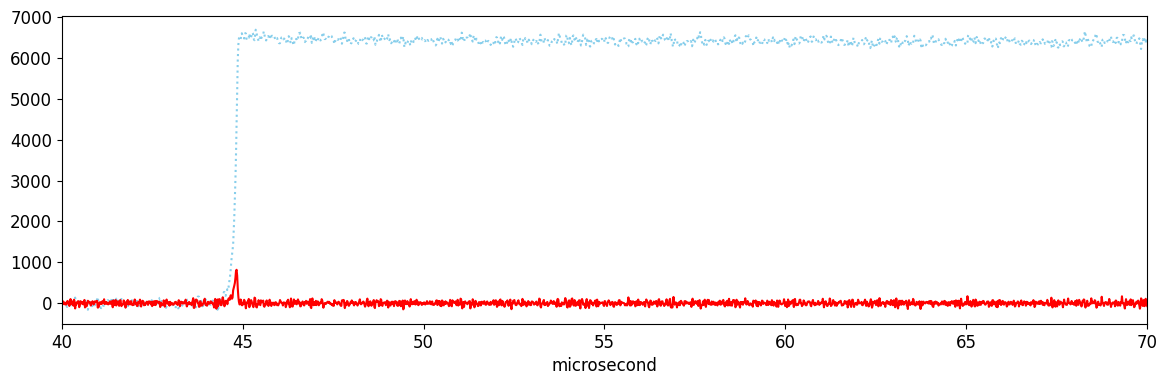

In [26]:
browser = WaveformBrowser(
    data_file,
    "geds/raw",
    dsp_config=dsp_config,
    lines=[
        "wf_pz",
        "curr",
    ],
    styles=[
        {"color": ["skyblue"], "ls": [":"]},
        {"color": ["r"]},
    ],
    x_lim=("40*us", "70*us"),
)
browser.draw_entry(entry_no)

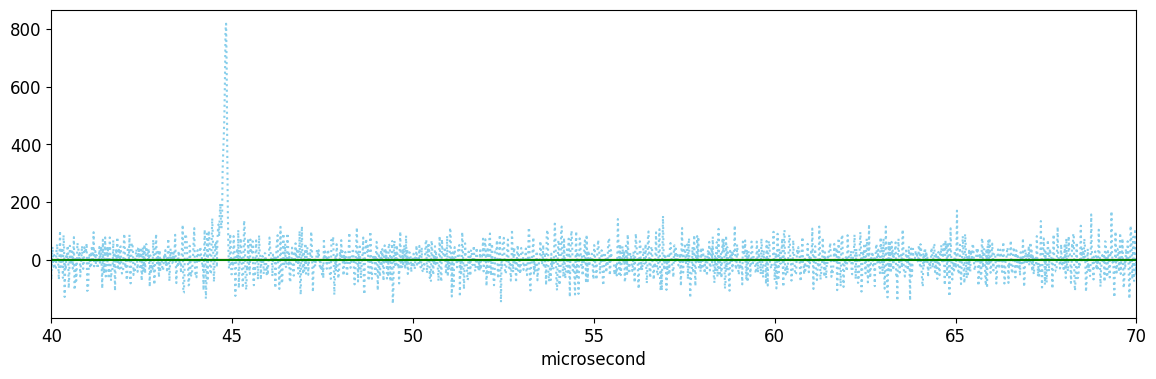

In [27]:
browser = WaveformBrowser(
    data_file,
    "geds/raw",
    dsp_config=dsp_config,
    lines=["curr", "curr_gaus", "A_gaus"],
    styles=[{"color": ["skyblue"], "ls": [":"]}, {"color": ["r"]}, {"color": ["g"]}],
    x_lim=("40*us", "70*us"),
)
browser.draw_entry(entry_no)

In [28]:
build_dsp(
    data_file,
    dsp_out="./example_dsp_file.lh5",
    dsp_config=dsp_config,
    write_mode="r",  # used to overwrite an existing file
)

In [30]:
ls("example_dsp_file.lh5")
show("example_dsp_file.lh5")

/
└── geds · struct{dsp} 
    └── dsp · table{A_gaus,bl,bl_sig,channel,ftp,timestamp,tp_0,trapEftp,trapEmax,trapTmax} 
        ├── A_gaus · array<1>{real} 
        ├── bl · array<1>{real} 
        ├── bl_sig · array<1>{real} 
        ├── channel · array<1>{real} 
        ├── ftp · array<1>{real} 
        ├── timestamp · array<1>{real} 
        ├── tp_0 · array<1>{real} 
        ├── trapEftp · array<1>{real} 
        ├── trapEmax · array<1>{real} 
        └── trapTmax · array<1>{real} 


In [31]:
obj = read("geds/dsp", "./example_dsp_file.lh5")
print(
    f"We have saved the following list of outputs from our DSP routine: {list(obj.keys())}"
)
print(
    f"There are {len(obj)} rows of values, corresponding to that same number of waveforms."
)

We have saved the following list of outputs from our DSP routine: ['A_gaus', 'bl', 'bl_sig', 'channel', 'ftp', 'timestamp', 'tp_0', 'trapEftp', 'trapEmax', 'trapTmax']
There are 100 rows of values, corresponding to that same number of waveforms.


In [32]:
read_as("geds/dsp", "./example_dsp_file.lh5", "pd")

,A_gaus,bl,bl_sig,channel,ftp,timestamp,tp_0,trapEftp,trapEmax,trapTmax
0,0.0,13720.968750,94.490707,53,54336.0,0.794660,44592.0,2310.669189,2319.071777,52944
1,0.0,13050.674805,50.100597,60,53168.0,0.796899,43424.0,5678.894531,5761.768555,53824
2,0.0,13453.005859,65.760880,40,54160.0,0.799604,44416.0,6428.772461,6439.731445,52912
3,0.0,11828.862305,64.085381,41,54000.0,0.799604,44256.0,9124.365234,9147.147461,52816
4,0.0,14342.213867,46.583649,60,53152.0,0.801617,43408.0,2672.938965,2672.945312,53136
...,...,...,...,...,...,...,...,...,...,...
95,0.0,27145.410156,437.696960,53,54352.0,0.965948,44608.0,3191.124023,3199.575684,52880
96,0.0,14568.882812,49.303154,60,53056.0,0.971051,43312.0,2631.415527,2636.029541,53232
97,0.0,15455.618164,90.539101,53,54320.0,0.973319,44576.0,26523.931641,26580.843750,53024
98,0.0,9922.455078,73.784843,30,54160.0,0.974689,44416.0,4229.133301,4232.768066,54448
